# Switching Linear Dynamical System Demo

Switching Linear Dynamical Systems (SLDS) provide a natural way of combining Linear Dynamical Systems with Hidden Markov Models. They allow us to approximate a system that has globally non-linear dynamics by a series of linear systems. A good reference for these types of systems is [Variational Inference for State Space models](https://www.cs.toronto.edu/~hinton/absps/switch.pdf) by Ghahramani and Hinton.

An LDS comprises $K$ discrete hidden states, which evolve according to a Markov chain. We'll call the hidden state $z$, and use the notation $z_t = k$ to mean that the system is in state $k$ at time $t$. The Markov chain for the hidden state is specified by a state-transition matrix $\mathbf{Q}$, where $\mathbf{Q}_{ij} = \mathbb{P}(z_t = j \mid z_{t-1} = i)$.

## Generative Model for SLDS

The generative model for an SLDS combines an HMM with a set of linear dynamical systems as follows. In addition to the discrete state, we have a continuous latent state $x_t \in \mathbb{R}^D$ and an observation $y_t \in \mathbb{R}^N$. Each discrete state ${1...K}$ is associated with a different dynamics matrix $\mathbf{A}_{k}$ and a different measurement matrix $\mathbf{C}_{k}$. Formally, we generate data from an SLDS as follows:

### Discrete State Update

At each time step, sample a new discrete state $z_t | z_{t - 1}$ with probabilities given by a Markov chain.

### Continuous State Update

Update the state using the dynamics matrix corresponding to the new discrete state:
$$
x_t = \mathbf{A}_{k} x_{t-1} + \mathbf{V}_{k} u_t + \mathbf{b}_{k} + \mathbf{w}_t
$$
where $\mathbf{A}_{z_t}$ is the dynamics matrix corresponding to discrete state $k$. $u_t$ is the input vector (specified by the user, not inferred by SSM) and $\mathbf{V}_{k}$ is the corresponding control matrix. The vector $\mathbf{b}_{k}$ is an offset vector, which can drive the dynamics in a particular direction. The term $\mathbf{w}_t$ is a noise term, which perturbs the dynamics. Most commonly these are modeled as zero-mean multivariate Gaussians, but one nice feature of SSM is that it supports many distributions for these noise terms. 

### Emission

We now make an observation of the state, according to the specified observation model. In the general case, the state controls the observation via a Generalized Linear Model:
$$
y_t \sim \mathbb{P}(\nu (\mathbf{C}_{k} x_t + \mathbf{d}_{k} + \mathbf{F}_{k} u_t + \mathbf{v}_{t}))
$$
where $\mathbb{P}$ is a probability distribution. The inner arguments form an affine measurement of the state, which is then passed through the inverse link function $\nu$. In this case, $\mathbf{C}_{k}$ is the measurement matrix corresponding to discrete state $k$, $\mathbf{d}_{k}$ is an offset or bias term corresponding to discrete state $k$, and $\mathbf{F}_{k}$ is called the feedthrough matrix or passthrough matrix (it passes the input directly to the emission). In the Gaussian case, the emission can simply be written as:
$$
y_t = \mathbf{C}_{k} x_t + \mathbf{d}_{k} + \mathbf{F}_{k} u_t + \mathbf{v}_t
$$
where $\mathbf{v}_t$ is a Gaussian r.v. 

This notebook demonstrates how to implement and fit a Switching Linear Dynamical System (SLDS) model using Gibbs Sampling implemented in JAX. 

## Gibbs Sampling for SLDS Inference

Inferring the latent states and parameters of an SLDS is a challenging task due to the interdependence between discrete and continuous states. Gibbs sampling provides an effective approach to this problem by iteratively sampling from the conditional distributions of the model components.

In the context of SLDS, Gibbs sampling operates as follows:

1. **Sample Discrete States**: Given the continuous states and parameters, sample the discrete states $z_{1:T}$ from $p(z_{1:T} | x_{1:T}, y_{1:T}, \theta)$.
   This step leverages the Markovian structure of the discrete states and can be efficiently performed using dynamic programming algorithms like the forward-backward algorithm.

2. **Sample Continuous States**: Given the discrete states and parameters, sample the continuous states $x_{1:T}$ from $p(x_{1:T} | z_{1:T}, y_{1:T}, \theta)$.
   This step can be performed using Kalman smoothing within each segment of constant discrete state.

3. **Update Parameters**: Given the latent states, update the model parameters $\theta$ (including transition probabilities, dynamics matrices, and emission parameters) based on their posterior distributions.

These steps are repeated for a number of iterations, gradually improving our estimates of the latent states and parameters. The power of Gibbs sampling lies in its ability to break down the complex joint distribution into more manageable conditional distributions.

## 1. Setup 

We'll start by importing the necessary libraries and setting up our environment.

In [4]:
import sys
import os
current_dir = os.path.dirname(os.path.abspath('__file__'))
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import seaborn as sns
from jax import grad, jit, vmap, lax
from jaxtyping import Array, Float
from typing import Callable
from tensorflow_probability.substrates import jax as tfp
import equinox as eqx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import tensorflow_probability.substrates.jax as tfp


tfd = tfp.distributions
tfb = tfp.bijectors
MVN = tfd.MultivariateNormalFullCovariance
MVNDiag = tfd.MultivariateNormalDiag

from dynamax import hidden_markov_model as hmm
from dynamax import linear_gaussian_ssm as lgssm
from models import SLDS
from slds_eqx.gibbs import fit_gibbs

# random seed for reproducibility
key = jr.PRNGKey(0)


## 2. Data Generation

To test our SLDS model and inference algorithm, we'll first generate synthetic data. This function creates a realistic SLDS model and samples data from it. Here's what it does:

1. Creates a transition matrix for the discrete states
2. Generates dynamics matrices for each state
3. Creates an emission matrix
4. Constructs the full SLDS model
5. Samples a sequence of discrete states, continuous latent states, and observations

Key components:
- `num_states`: Number of discrete states in the model
- `latent_dim`: Dimensionality of the continuous latent state
- `emission_dim`: Dimensionality of the observed data
- `num_timesteps`: Length of the time series to generate

The function returns the true SLDS model and the generated data (discrete states, continuous states, and observations).

In [5]:
def generate_synthetic_data(key, num_states, latent_dim, emission_dim, num_timesteps):
    #Create transition matrix
    p = jnp.arange((num_states)).astype(float)**10
    p /= p.sum()
    P = jnp.zeros((num_states, num_states))
    for k, p in enumerate(p[::-1]):
        P += jnp.roll(p * jnp.eye(num_states), k, axis=1)
    
    plt.imshow(P, vmin=0, vmax=1, cmap="Greys")
    plt.xlabel("next state")
    plt.ylabel("current state")
    plt.title("transition matrix")
    plt.colorbar()

    #Create dynamics matrices
    rot = lambda theta: jnp.array([[jnp.cos(theta), -jnp.sin(theta)],
                                   [jnp.sin(theta), jnp.cos(theta)]])
    angles = jnp.linspace(0, 2 * jnp.pi, num_states, endpoint=False)
    theta = -jnp.pi / 25
    As = jnp.array([0.8 * rot(theta) for _ in range(num_states)])
    bs = jnp.column_stack([jnp.cos(angles), jnp.sin(angles)])
    Qs = jnp.tile(0.001 * jnp.eye(latent_dim), (num_states, 1, 1))

    # Create emission matrix
    key, subkey = jr.split(key)
    C = jr.normal(subkey, (emission_dim, latent_dim))
    d = jnp.zeros(emission_dim)
    R = jnp.eye(emission_dim)

    # Create SLDS model
    log_P = tfb.SoftmaxCentered().inverse(P+1e-4)#
    log_Qs = tfb.Softplus(low=1e-5).inverse(vmap(jnp.diag)(Qs))
    log_R = tfb.Softplus(low=1e-5).inverse(jnp.diag(R))

    true_slds = SLDS(num_states, latent_dim, emission_dim, log_P, As, bs, log_Qs, C, d, log_R)
    
    # Sample from the model
    key, subkey = jr.split(key)
    zs, xs, ys = true_slds.sample(subkey, num_timesteps)
    return true_slds, zs, xs, ys

Here, we set the parameters for our SLDS:
- 5 discrete states
- Latent state of dimension 2
- Emissions of dimension 100
- 5000 time steps

These will serve as our ground truth data for evaluating the inference algorithm. The high-dimensional emissions (100D) from a low-dimensional latent state (2D) create a challenging and realistic scenario for our inference task. The synthetic data is such that the probability of transition from one state to another is maximum when there is no change in state and diffuses as we attempt to transition to states further away from our current state.

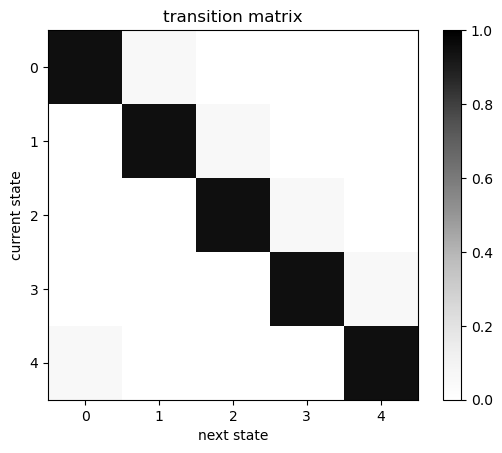

In [6]:
num_states, latent_dim, emission_dim, num_timesteps = 5, 2, 100, 5000
key, subkey = jr.split(key)
true_slds, true_zs, true_xs, ys = generate_synthetic_data(subkey, num_states, latent_dim, emission_dim, num_timesteps)

Let's take a closer look at our generated SLDS model and the synthetic data:

- `true_slds.transition_logits`: These are the log-probabilities of transitioning between discrete states. In SLDS theory, these logits define the Markov chain governing the switching process. The actual transition probabilities can be obtained by applying the softmax function to these logits.

- `true_zs.shape`: This shows the shape of our discrete state sequence. In SLDS, $z_t$ represents the active dynamical system at time $t$. The length of this sequence should match our specified `num_timesteps`.

- `true_xs.shape`: This displays the shape of our continuous latent state sequence. In SLDS, $x_t$ evolves according to the linear dynamical system specified by the current $z_t$. The first dimension should match `num_timesteps`, and the second should be our `latent_dim`.

- `ys.shape`: This shows the shape of our observation sequence. In SLDS, $y_t$ is generated from $x_t$ through the emission model. The first dimension should match `num_timesteps`, and the second should be our `emission_dim`.

- `true_zs`: This prints out the actual sequence of discrete states. In a well-specified SLDS, we expect to see periods where the system stays in one state, punctuated by transitions to other states.

In [7]:
print(f"Logits: {true_slds.transition_logits}")

Logits: [[ 9.1547365e+00  6.2796855e+00  2.3259559e+00  8.9797974e-03]
 [-8.9797974e-03  9.1457567e+00  6.2707057e+00  2.3169761e+00]
 [-2.3169761e+00 -2.3259559e+00  6.8287802e+00  3.9537296e+00]
 [-3.9537296e+00 -6.2707057e+00 -6.2796855e+00  2.8750508e+00]
 [-2.8750508e+00 -6.8287802e+00 -9.1457567e+00 -9.1547365e+00]]


In [8]:
print(true_zs.shape)
print(true_xs.shape)
print(ys.shape)
print(true_zs)

(5000,)
(5000, 2)
(5000, 100)
[1 1 1 ... 0 0 0]


## Visualizing SLDS States and Time Series

The `plot_states_and_timeseries` function creates a visualization that combines the discrete states and continuous time series of our SLDS.

1. **Discrete States Visualization**:
   - The background of the plot shows a color-coded representation of the discrete states ($z_t$).
   - Each color corresponds to a different discrete state.
   - The x-axis represents time steps.
   - Vertical "stripes" of the same color indicate periods where the system remains in the same discrete state.
   - Color changes represent transitions between discrete states.

2. **Continuous States Visualization**:
   - Two lines are plotted over the discrete state background:
     - Red line: represents the first dimension of the continuous latent state ($x_t[0]$).
     - Blue line: represents the second dimension of the continuous latent state ($x_t[1]$).
   - The y-axis represents the value of these continuous states.

3. **Emissions Plot**:
   - The second plot shows the first two dimensions of the (noisy) emissions ($y_t$) instead of the latent states.
   - Compare this to the latent states plot to see how the emission process transforms the latent dynamics.

4. **Key Insights**:
   - State Persistence: Look for extended periods of the same color, indicating the system staying in one discrete state.
   - Transition Frequency: The frequency of color changes indicates how often the system switches between discrete states.
   - State-Dependent Dynamics: Observe how the continuous trajectories behave differently in different colored regions.
   - Emission Transformation: Compare the smoothness and patterns in the latent state plot versus the emissions plot.

By analyzing these plots, we can gain insights into the underlying structure and behavior of our SLDS, including how often it switches between discrete states and how these switches affect the continuous dynamics of the system.

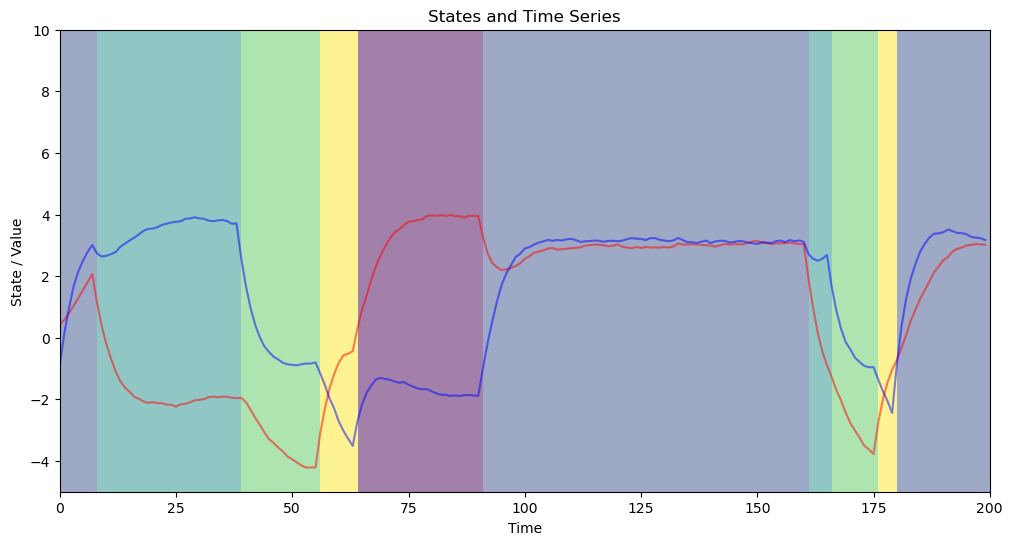

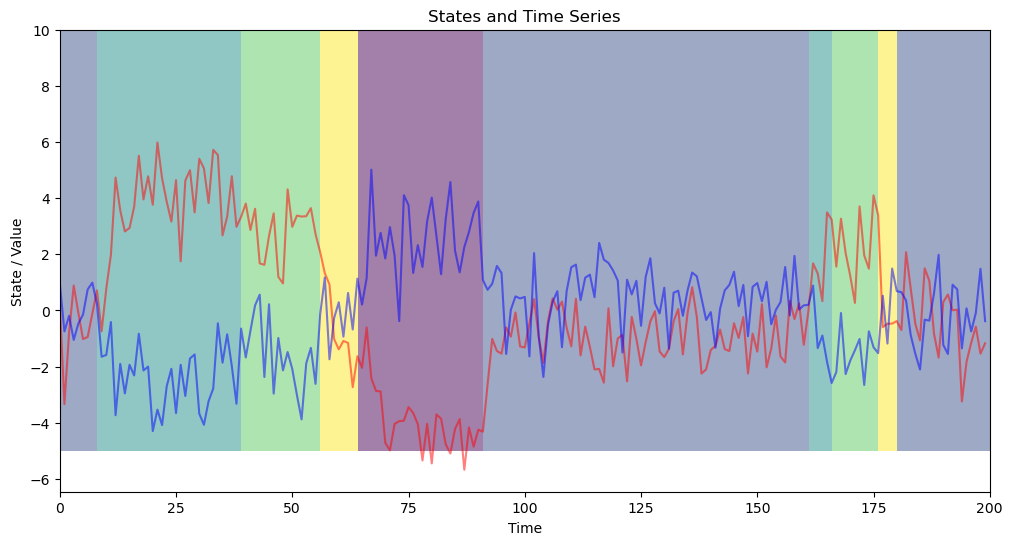

In [9]:
def plot_states_and_timeseries(zs, vs, vs_std=None, spc=5):
    T, dim = vs.shape
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    ax.imshow(zs[None, :], 
              extent=(0, T, -spc, dim * spc),
              cmap="viridis",
              alpha=0.5,
              aspect="auto")
    ax.plot(vs[:, 0], color="r", alpha=0.5)
    ax.plot(vs[:, 1], color="b", alpha=0.5)
    ax.set_title("States and Time Series")
    ax.set_xlabel("Time")
    ax.set_ylabel("State / Value")
    return fig, ax

# Plot latent states
fig, ax = plot_states_and_timeseries(true_zs[:200], true_xs[:200])
plt.show()

# Plot emissions (first two dimensions for visibility)
fig, ax = plot_states_and_timeseries(true_zs[:200], ys[:200, :2])
plt.show()

## 3. Initialize the SLDS model

Here we create an initial SLDS model by perturbing the true parameters with small Gaussian noise (scale 0.1) while maintaining the structure of the true model. This allows us to simulate having a good, but imperfect, initial guess of parameters and provides a starting point for inference to demonstrate parameter recovery.

By starting with this initialized model, our inference algorithm can work towards recovering the true parameters of the system and we can test its ability to refine our initial estimates.

In [10]:
def initialize_model(key, true_slds):
    # Slightly perturb the true parameters
    perturb = lambda x: x + 0.1 * jr.normal(key, x.shape)
    init_slds = SLDS(
        true_slds.num_states,
        true_slds.latent_dim,
        true_slds.emission_dim,
        perturb(true_slds.transition_logits),
        perturb(true_slds.dynamics_matrices),
        perturb(true_slds.dynamics_biases),
        perturb(true_slds.dynamics_diag_logvars),
        perturb(true_slds.emission_matrix),
        perturb(true_slds.emission_bias),
        perturb(true_slds.emission_diag_logvars)
    )
    return init_slds

In [11]:
key, subkey = jr.split(key)
init_slds = initialize_model(subkey, true_slds)

In [12]:
print(f"Perturbed Logits: {init_slds.transition_logits}")

Perturbed Logits: [[ 9.074916    6.186605    2.2518263  -0.02338149]
 [ 0.04725956  9.297068    6.242708    2.4151518 ]
 [-2.440708   -2.31648     6.6948266   4.0269146 ]
 [-4.0571203  -6.45061    -6.11063     2.9656212 ]
 [-2.808271   -7.016446   -9.185459   -9.301804  ]]


# Alternative Random Initialization (Independent of True Parameters)

In this example, we use a bunch of heuristics to intiailize the SLDS parameters, which we feel serves the purpose of pseudo-random initialization when the true features of the model are unknown.

In [ ]:
def random_init_slds(key, num_states, latent_dim, emission_dim, observations):
    """
    Randomly initialize an SLDS model using heuristics.
    
    Args:
    key: JAX random key
    num_states: Number of discrete states
    latent_dim: Dimensionality of the latent space
    emission_dim: Dimensionality of the observations
    observations: Array of shape (num_timesteps, emission_dim)
    
    Returns:
    An initialized SLDS object
    """
    num_timesteps = observations.shape[0]
    
    # 1. Initialize continuous states using PCA (reducing dimensionality from emission_dim to latent_dim)
    pca = PCA(n_components=latent_dim)
    initial_xs = pca.fit_transform(observations)
    
    # 2. Initialize discrete states using K-means on the PCA results
    kmeans = KMeans(n_clusters=num_states, random_state=0)
    initial_zs = kmeans.fit_predict(initial_xs)
    
    # 3. Initialize transition matrix
    key, subkey = jr.split(key)
    transition_matrix = jr.dirichlet(subkey, jnp.ones(num_states), shape=(num_states,))
    transition_logits = tfb.SoftmaxCentered().inverse(transition_matrix)
    
    # 4. Initialize dynamics matrices and biases
    key, subkey = jr.split(key)
    dynamics_matrices = jr.normal(subkey, (num_states, latent_dim, latent_dim)) * 0.1
    dynamics_matrices += jnp.eye(latent_dim)  # Add identity to ensure stability
    
    key, subkey = jr.split(key)
    dynamics_biases = jr.normal(subkey, (num_states, latent_dim)) * 0.1
    
    # 5. Initialize dynamics covariances
    key, subkey = jr.split(key)
    dynamics_diag_logvars = jr.normal(subkey, (num_states, latent_dim)) - 2  # Start with small variances
    
    # 6. Initialize emission matrix and bias
    emission_matrix = pca.components_.T  # Use PCA components as initial emission matrix
    
    key, subkey = jr.split(key)
    emission_bias = jr.normal(subkey, (emission_dim,)) * 0.1
    
    # 7. Initialize emission covariance
    key, subkey = jr.split(key)
    emission_diag_logvars = jr.normal(subkey, (emission_dim,)) - 2  # Start with small variances
    
    # 8. Create and return the SLDS object
    return SLDS(num_states, latent_dim, emission_dim,
                transition_logits, dynamics_matrices, dynamics_biases, dynamics_diag_logvars,
                emission_matrix, emission_bias, emission_diag_logvars)


In [ ]:
# Initialize the Random SLDS model
key = jr.PRNGKey(0)
init_slds = random_init_slds(key, num_states, latent_dim, emission_dim, ys)

## 4. Fitting the Model

The `fit_gibbs` function implements Gibbs sampling to infer the latent states and parameters of our SLDS. This process embodies the core of SLDS theory and Bayesian inference by alternating between updating discrete states, continuous states, and model parameters. It captures the switching nature of the system, where different linear dynamics govern at different times, while leveraging the linear Gaussian structure within each regime. The algorithm uses stochastic optimization to adjust model parameters, balancing between fitting the data and maintaining consistency with previous estimates. 

Starting from perturbed initial conditions, this approach tests the robustness of our inference method in recovering true system dynamics from noisy observations. As the algorithm iterates, it converges towards a posterior distribution that best explains the observed data, demonstrating how complex, switching dynamics can be inferred from imperfect measurements.

In [13]:
key, subkey = jr.split(key)
fitted_slds, lps, fitted_zs, fitted_xs = fit_gibbs(
    init_slds, subkey, ys, 
    initial_zs=jnp.asarray(jr.randint(subkey, (num_timesteps,), 0, num_states), dtype=jnp.int32),
    initial_xs=jr.normal(subkey, (num_timesteps, latent_dim)),
    num_iters=100, lr=1e-3, reg_schedule=lambda t: 1.0 * (0.99 ** t),
    param_update_iters=10
)

## 5. Model Evaluation

In this section, we employ different metrics to see how well gibbs sampling allows us to fit the initial SLDS to our true model.

The `compare_parameters` function evaluates the performance of our Gibbs sampling algorithm in recovering the true parameters of the SLDS. By providing both visual heatmap comparisons and quantitative metrics like Mean Squared Error and correlation coefficients, it offers a comprehensive assessment of how well our inference method captures the underlying structure of the SLDS. 

By visualizing these parameters as heatmaps, we gain insights into the structure of both the true and inferred models. The transition matrix heatmap should reveal patterns of state persistence (high values along the diagonal) and preferred state transitions (off-diagonal hot spots). For dynamics matrices, we expect to see different patterns for each discrete state, reflecting varying linear dynamics. The emission matrix heatmap illustrates how latent states map to observations, often showing sparse or structured patterns depending on the system's nature.

Ideally, the inferred parameter heatmaps should closely resemble the true ones, indicating successful recovery of the underlying SLDS structure. Discrepancies can point to specific challenges in inference, such as difficulty in distinguishing certain states or capturing rapid transitions. The quantitative metrics (MSE and correlation) provide a numerical assessment of this similarity, with lower MSE and higher correlation indicating better parameter recovery.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def compare_parameters(true_slds, fitted_slds):
    fig, axs = plt.subplots(3, 2, figsize=(15, 20))
    
    # Transition Matrix
    sns.heatmap(true_slds.transition_matrix, ax=axs[0, 0], cmap="YlOrRd")
    axs[0, 0].set_title("True Transition Matrix")
    sns.heatmap(fitted_slds.transition_matrix, ax=axs[0, 1], cmap="YlOrRd")
    axs[0, 1].set_title("Fitted Transition Matrix")
    
    # Dynamics Matrices (first state as example)
    sns.heatmap(true_slds.dynamics_matrices[0], ax=axs[1, 0], cmap="coolwarm")
    axs[1, 0].set_title("True Dynamics Matrix (State 0)")
    sns.heatmap(fitted_slds.dynamics_matrices[0], ax=axs[1, 1], cmap="coolwarm")
    axs[1, 1].set_title("Fitted Dynamics Matrix (State 0)")
    
    # Emission Matrix
    sns.heatmap(true_slds.emission_matrix, ax=axs[2, 0], cmap="viridis")
    axs[2, 0].set_title("True Emission Matrix")
    sns.heatmap(fitted_slds.emission_matrix, ax=axs[2, 1], cmap="viridis")
    axs[2, 1].set_title("Fitted Emission Matrix")
    
    plt.tight_layout()
    plt.show()
    
    # Compute and print some metrics
    mse_transition = np.mean((true_slds.transition_matrix - fitted_slds.transition_matrix)**2)
    mse_dynamics = np.mean((true_slds.dynamics_matrices - fitted_slds.dynamics_matrices)**2)
    mse_emission = np.mean((true_slds.emission_matrix - fitted_slds.emission_matrix)**2)
    
    print(f"Mean Squared Error - Transition Matrix: {mse_transition:.4f}")
    print(f"Mean Squared Error - Dynamics Matrices: {mse_dynamics:.4f}")
    print(f"Mean Squared Error - Emission Matrix: {mse_emission:.4f}")
    
    # Compute correlation coefficients
    corr_transition = np.corrcoef(true_slds.transition_matrix.flatten(), fitted_slds.transition_matrix.flatten())[0, 1]
    corr_dynamics = np.corrcoef(true_slds.dynamics_matrices.flatten(), fitted_slds.dynamics_matrices.flatten())[0, 1]
    corr_emission = np.corrcoef(true_slds.emission_matrix.flatten(), fitted_slds.emission_matrix.flatten())[0, 1]
    
    print(f"\nCorrelation Coefficient - Transition Matrix: {corr_transition:.4f}")
    print(f"Correlation Coefficient - Dynamics Matrices: {corr_dynamics:.4f}")
    print(f"Correlation Coefficient - Emission Matrix: {corr_emission:.4f}")

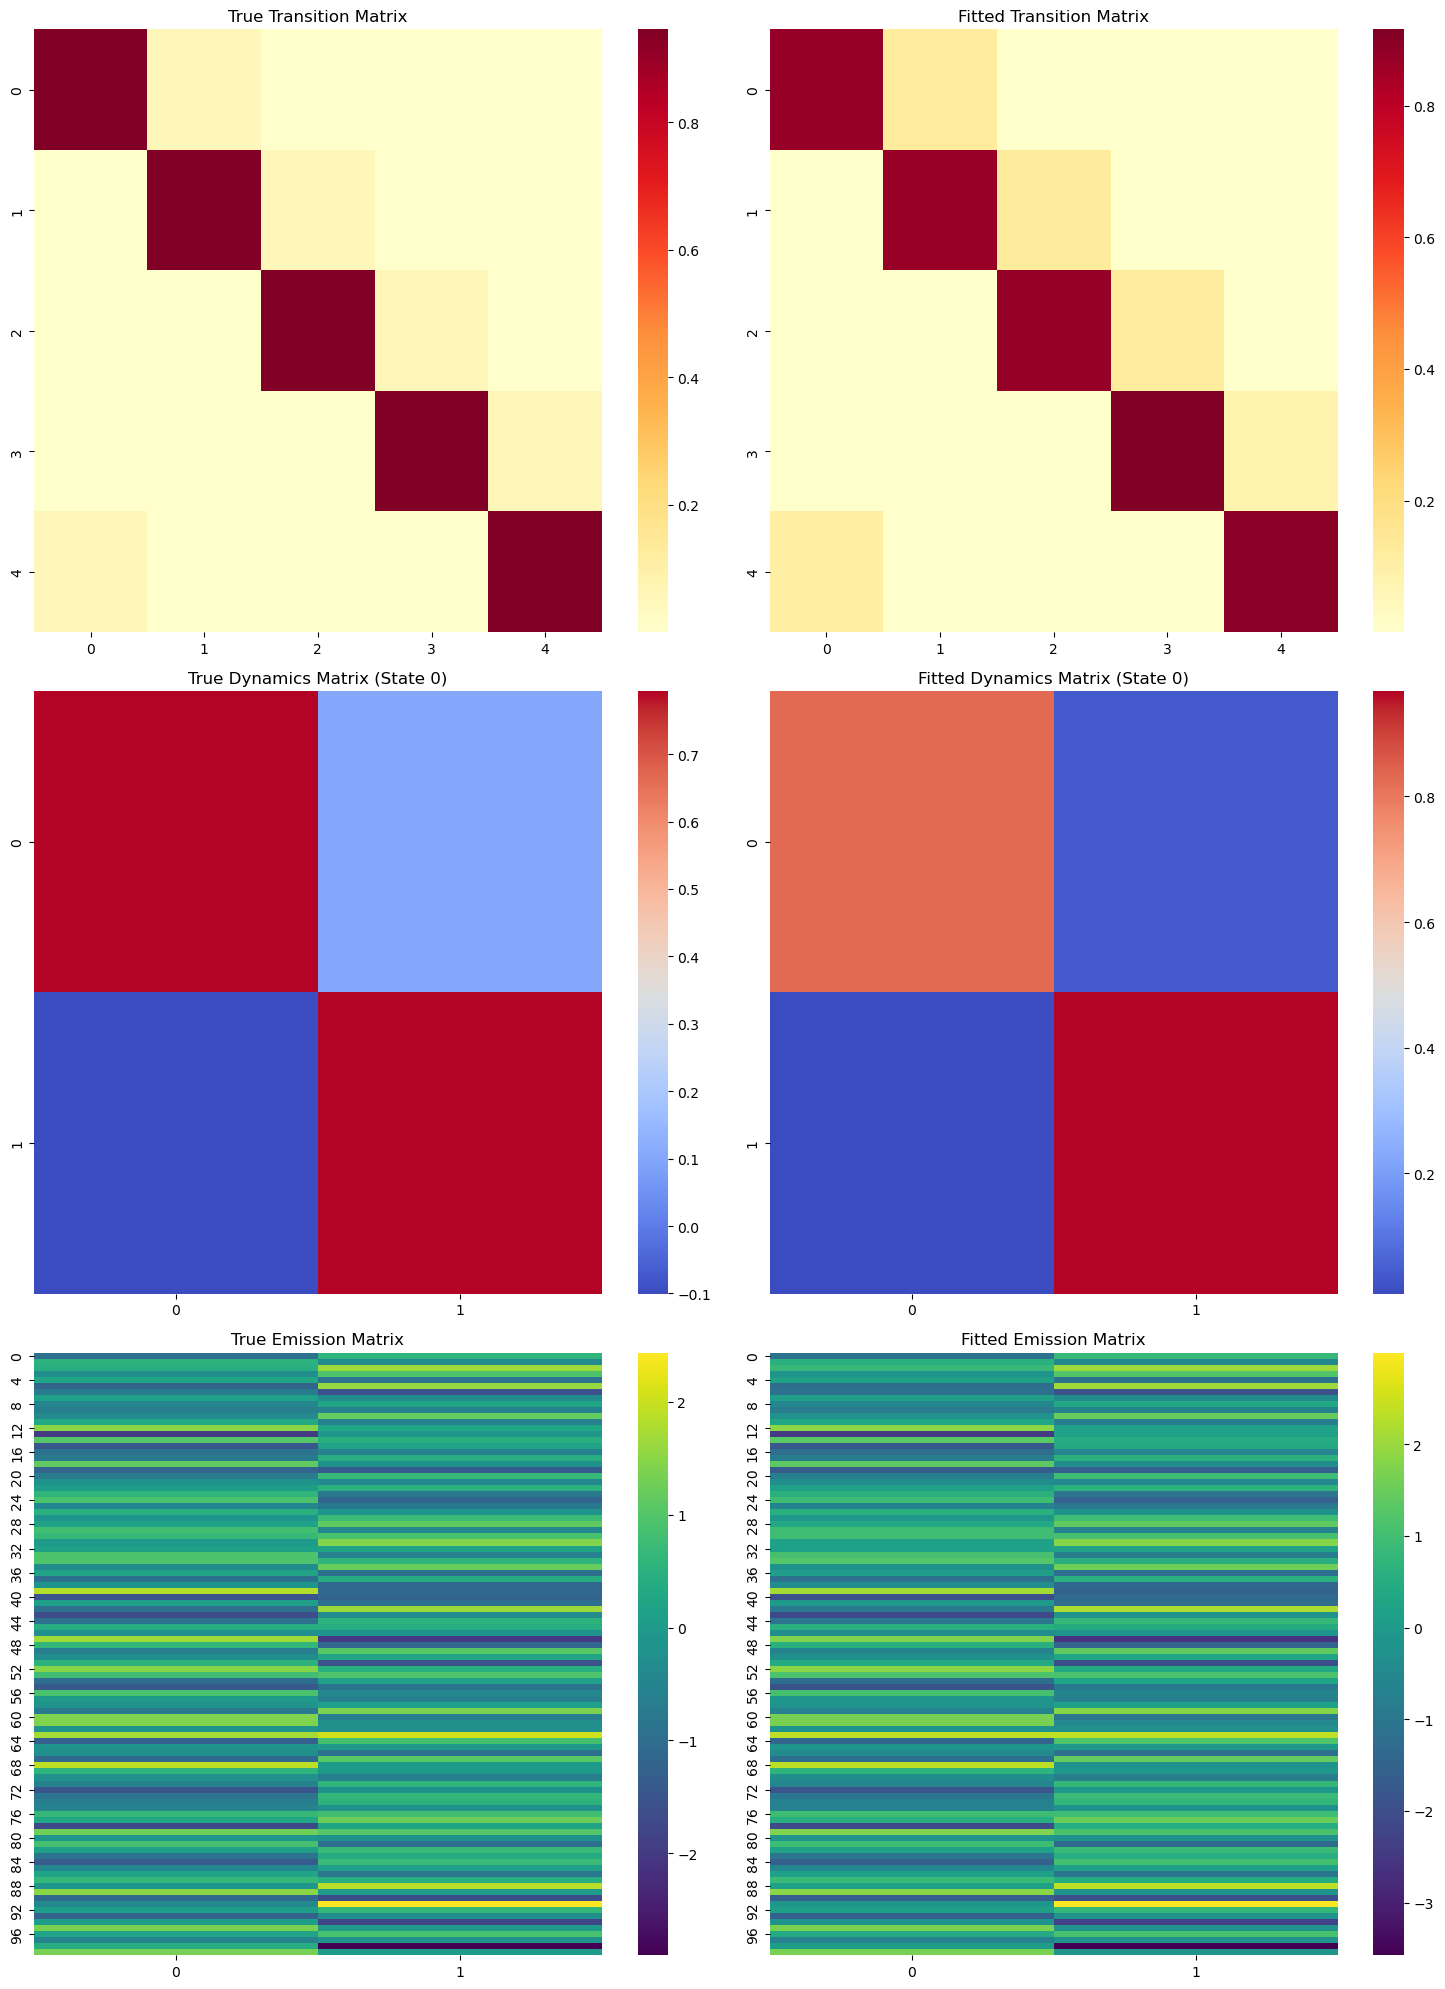

Mean Squared Error - Transition Matrix: 0.0015
Mean Squared Error - Dynamics Matrices: 0.0140
Mean Squared Error - Emission Matrix: 0.0621

Correlation Coefficient - Transition Matrix: 0.9970
Correlation Coefficient - Dynamics Matrices: 0.9803
Correlation Coefficient - Emission Matrix: 0.9940


In [15]:
compare_parameters(true_slds, fitted_slds)

### Discrete State Inference

After fitting our SLDS model, we evaluate the accuracy of our inferred discrete states using two metrics:

1. **Normalized Mutual Information (NMI)**: 
   This metric measures the mutual dependence between the true and inferred discrete states. It quantifies how much information the inferred states provide about the true states. NMI values range from 0 to 1, where 1 indicates perfect correlation.

2. **Adjusted Rand Index (ARI)**:
   This metric measures the similarity between the true and inferred state clusterings. It accounts for chance agreement and can take values between -1 and 1. A value of 1 indicates perfect agreement, while 0 represents random labeling.

In [16]:
nmi = normalized_mutual_info_score(true_zs, fitted_zs)
ari = adjusted_rand_score(true_zs, fitted_zs)
print(f"Normalized Mutual Information: {nmi}")
print(f"Adjusted Rand Index: {ari}")

Normalized Mutual Information: 0.6043281756404119
Adjusted Rand Index: 0.5246006617381015


### Continuous State Inference

After inferring the continuous latent states of our SLDS model, we assess the accuracy of our estimates using two key metrics:

1. **Mean Squared Error (MSE)**:
   This metric quantifies the average squared difference between the true and inferred continuous states. A lower MSE indicates that our inferred states are closer to the true states on average.

2. **Correlation**:
   We calculate the Pearson correlation coefficient between the true and inferred continuous states. This metric measures the linear relationship between the two sets of states, with values ranging from -1 to 1. A value close to 1 indicates a strong positive linear relationship.

In [17]:
# Continuous State Inference
mse = jnp.mean((true_xs - fitted_xs)**2)
correlation = jnp.corrcoef(true_xs.ravel(), fitted_xs.ravel())[0, 1]
print(f"Mean Squared Error: {mse}")
print(f"Correlation: {correlation}")

Mean Squared Error: 0.4539651870727539
Correlation: 0.9891077280044556


### Log Probability Trajectory

To monitor the convergence of our Gibbs sampling algorithm, we plot the log probability trajectory across iterations. The log probability represents the likelihood of the observed data given the current model parameters and latent state estimates.

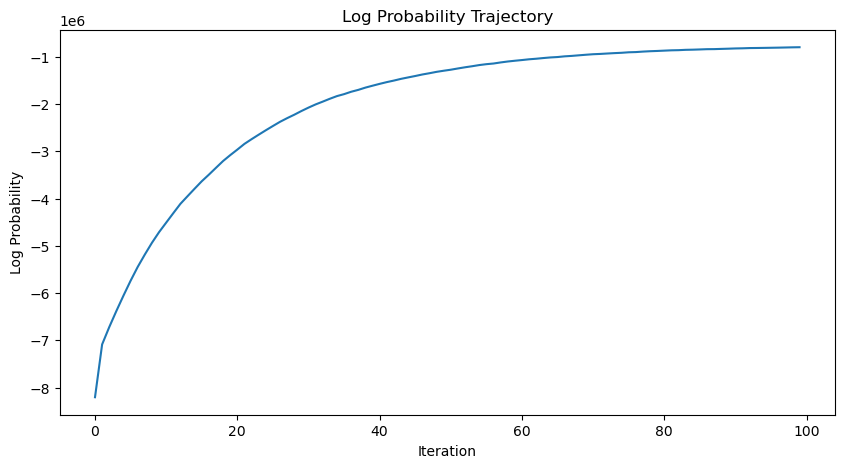

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(lps)
plt.xlabel("Iteration")
plt.ylabel("Log Probability")
plt.title("Log Probability Trajectory")
plt.show()

### Visualizing True and Fitted States

To gain intuitive insight into our SLDS inference results, we visualize both the true and fitted states. This visualization combines both discrete and continuous states:

The background colors represent the discrete states (zs), with each color corresponding to a different state.
The red and blue lines show the two dimensions of the continuous states (xs).

We plot the first 100 time steps for both true and fitted states to allow for detailed comparison. The fitted states should closely match the true states of the SLDS.

In [19]:
def plot_states_and_timeseries(zs, xs, title):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(zs[None, :], aspect="auto", cmap="Set3", interpolation="nearest")
    ax.plot(xs[:, 0], color="r", alpha=0.5)
    ax.plot(xs[:, 1], color="b", alpha=0.5)
    ax.set_title(title)
    plt.show()

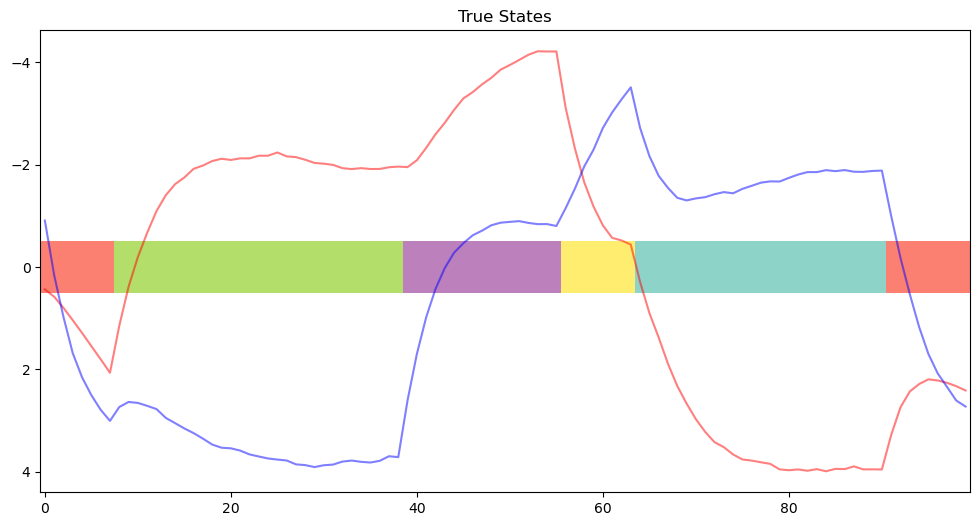

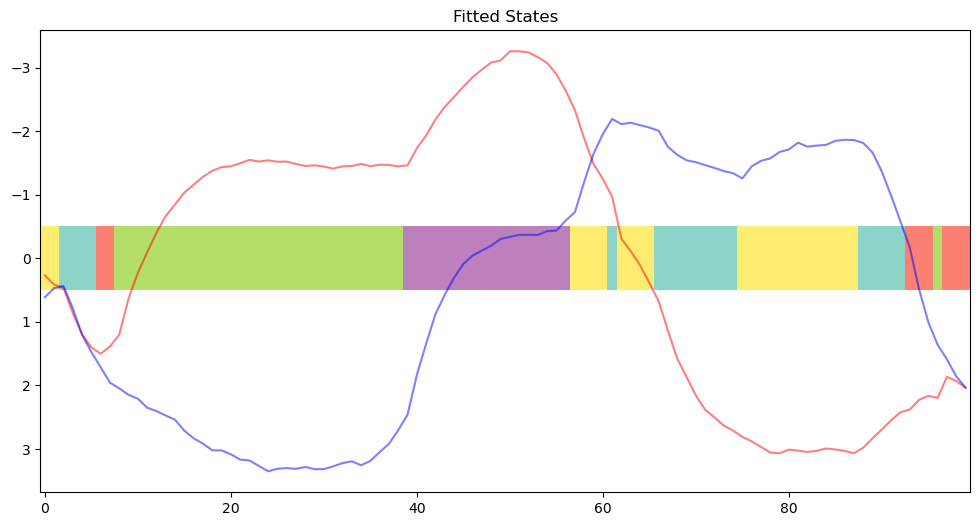

In [20]:
plot_states_and_timeseries(true_zs[:100], true_xs[:100], "True States")
plot_states_and_timeseries(fitted_zs[:100], fitted_xs[:100], "Fitted States")

### Sensitivity Analysis: Learning Rate and Regularization

To understand how our SLDS inference algorithm responds to different hyperparameters, we perform a sensitivity analysis on the learning rate and regularization scale.

In [23]:
# Sensitivity to learning rate and regularization
def run_with_different_hyperparameters():
    results = []
    for lr in [1e-4, 1e-3, 1e-2]:
        for reg_scale in [0.1, 1.0, 10.0]:
            key = jr.PRNGKey(int(lr * 1e4 + reg_scale * 10))
            reg_schedule = lambda t: reg_scale * (0.99 ** t)
            fitted_slds, lps, _, _ = fit_gibbs(init_slds, key, ys, 
                                               initial_zs=jr.randint(key, (num_timesteps,), 0, num_states),
                                               initial_xs=jr.normal(key, (num_timesteps, latent_dim)),
                                               num_iters=100, lr=lr, reg_schedule=reg_schedule)
            results.append((lr, reg_scale, lps))
    return results

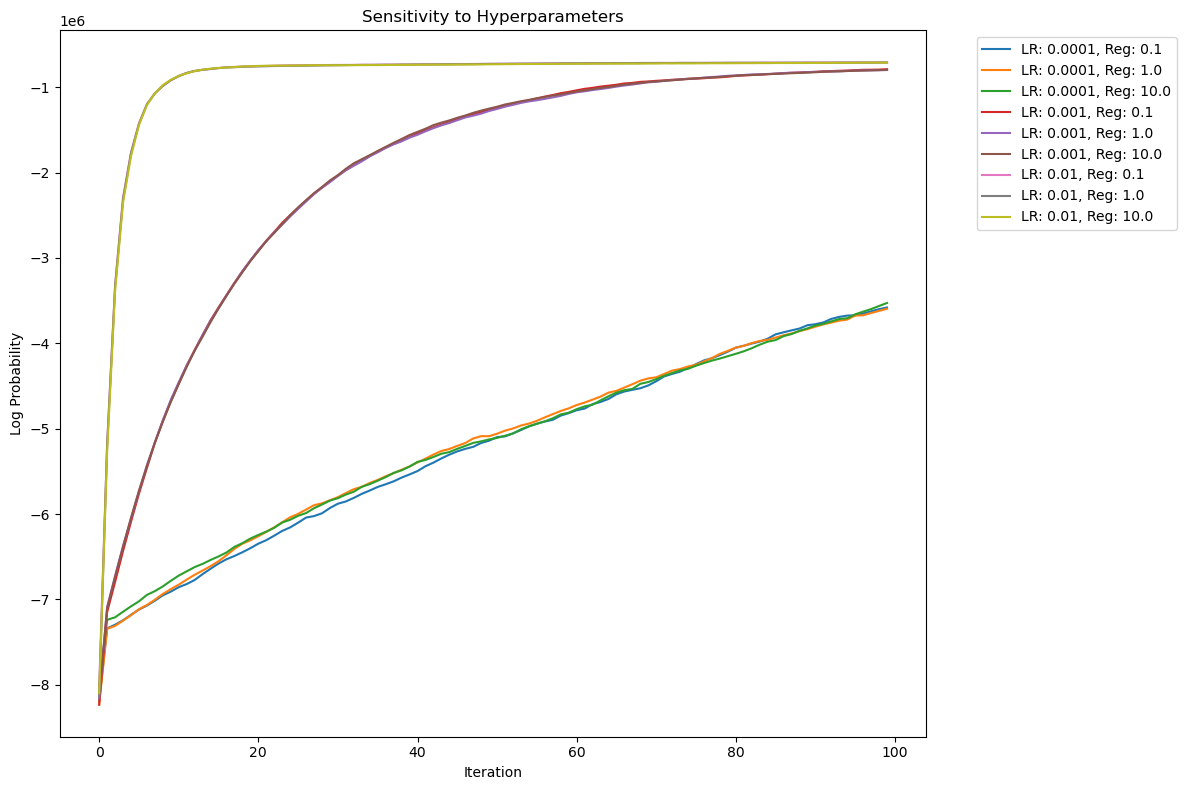

In [24]:
hyper_results = run_with_different_hyperparameters()
plt.figure(figsize=(12, 8))
for lr, reg_scale, lps in hyper_results:
    plt.plot(lps, label=f"LR: {lr}, Reg: {reg_scale}")
plt.xlabel("Iteration")
plt.ylabel("Log Probability")
plt.title("Sensitivity to Hyperparameters")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Totally random intialization (no peturbation)
Init continuous states --> Do PCA on the observations to get low dim embeddings and init C matrix to the principal components and X to the PCA embeddings
Init Discrete States randomly
Dynamics --> as identity matrix

BlackJax hamiltonian monte carlo --> update parameters --> hmc gives posterior distribution of parameters. Write another update_parameters_hmc function --> want to go to recurrent SLDS
adding recurrent SLDS object that inherits from SLDS --> transition matrix depends on z, x

freeze transition matrix --> fix a parameters --> easy way in optax/blackjax to specify which parameters to take grad w.r.t. --> look equinox docs (filters)